# Image PreProcess Check

In [ ]:
import rasterio

path = "/Volumes/Windows8_OS/Dataset/Dataset-OG/Images/Oil/00000.tif"

with rasterio.open(path) as src:
    print("Bands:", src.count)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Resolution:", src.res)


In [ ]:
import numpy as np
import rasterio

with rasterio.open(path) as src:
    vv = src.read(1)

print("Min:", np.nanmin(vv))
print("Max:", np.nanmax(vv))


In [ ]:
import matplotlib.pyplot as plt

plt.hist(vv.flatten(), bins=200)
plt.title("VV Histogram")
plt.show()


In [ ]:
plt.imshow(vv, cmap="gray")
plt.colorbar()
plt.title("Raw VV Display")
plt.show()


In [ ]:
with rasterio.open(path) as src:
    print(src.descriptions)


In [ ]:
def is_preprocessed_sar(img):
    if np.nanmin(img) < -5:
        return "ALREADY PREPROCESSED (dB)"
    if np.nanmax(img) > 100:
        return "RAW INTENSITY (NOT preprocessed)"
    return "UNKNOWN / PARTIAL"

print(is_preprocessed_sar(vv))


# Conversion from 2 bands to 1

In [ ]:
import rasterio
import numpy as np

with rasterio.open(path) as src:
    vv = src.read(1).astype(np.float32)
    vh = src.read(2).astype(np.float32)

In [ ]:
def normalize(img, pmin=2, pmax=98):
    lo, hi = np.percentile(img, (pmin, pmax))
    img = np.clip(img, lo, hi)
    return (img - lo) / (hi - lo + 1e-6)

vv_n = normalize(vv)
vh_n = normalize(vh)

# Model

In [ ]:
import os
import tensorflow as tf
import numpy as np
import rasterio
from tqdm import tqdm

In [ ]:
DATASET_ROOT = "/Volumes/Windows8_OS/Dataset/Dataset-OG"
IMAGES_ROOT = os.path.join(DATASET_ROOT, "Images")

OIL_DIR = os.path.join(IMAGES_ROOT, "Oil")
NO_OIL_DIR = os.path.join(IMAGES_ROOT, "No_Oil")

# Break

# Performance Optimizations Applied

1. **Pre-allocated arrays**: Faster than appending to lists
2. **Efficient normalization**: Handles NaN values properly
3. **TensorFlow dataset pipelines**: Parallel loading with AUTOTUNE
4. **Batch prefetching**: Overlaps data loading with training
5. **Early stopping**: Prevents overfitting and saves time
6. **Learning rate reduction**: Adapts to training progress

**Option 1**: Best for smaller datasets (loads all into memory)  
**Option 2**: Best for larger datasets (streams data on-demand)

In [ ]:
def normalize(img, pmin=2, pmax=98):
    """Fast normalization using percentile clipping."""
    # Handle NaN values
    valid_data = img[~np.isnan(img)]
    
    if len(valid_data) == 0:
        return img
    
    lo, hi = np.percentile(valid_data, (pmin, pmax))
    
    # Clip and normalize
    img_clipped = np.clip(img, lo, hi)
    
    # Avoid division by zero
    range_val = hi - lo
    if range_val < 1e-6:
        return np.zeros_like(img)
    
    return (img_clipped - lo) / range_val

In [ ]:
def load_sar_tiff(path):
    with rasterio.open(path) as src:
        vv = src.read(1).astype(np.float32)  # Band 1 = VV
        vh = src.read(2).astype(np.float32)  # Band 2 = VH

    vv = normalize(vv)
    vh = normalize(vh)

    x = np.stack([vv, vh], axis=-1)  # (H, W, 2)
    return x

In [ ]:
def load_detection_dataset(oil_dir, no_oil_dir, max_samples=None):
    """Load SAR images efficiently with optional sample limit."""
    oil_files = [os.path.join(oil_dir, f) for f in os.listdir(oil_dir) if f.endswith(".tif")]
    no_oil_files = [os.path.join(no_oil_dir, f) for f in os.listdir(no_oil_dir) if f.endswith(".tif")]
    
    # Optional: limit samples for faster testing
    if max_samples:
        oil_files = oil_files[:max_samples]
        no_oil_files = no_oil_files[:max_samples]

    print(f"Oil images: {len(oil_files)}")
    print(f"No-Oil images: {len(no_oil_files)}")
    
    total_samples = len(oil_files) + len(no_oil_files)
    
    # Pre-allocate arrays for better performance
    X = np.zeros((total_samples, 512, 512, 2), dtype=np.float32)
    y = np.zeros(total_samples, dtype=np.int32)
    
    idx = 0
    
    for path in tqdm(oil_files, desc="Loading OIL"):
        X[idx] = load_sar_tiff(path)
        y[idx] = 1
        idx += 1
    print("Oil Loaded")

    for path in tqdm(no_oil_files, desc="Loading NO-OIL"):
        X[idx] = load_sar_tiff(path)
        y[idx] = 0
        idx += 1
    print("No Oil Loaded")

    return X, y


In [ ]:
X, y = load_detection_dataset(OIL_DIR, NO_OIL_DIR)

print("Done")

In [ ]:
print("X shape:", X.shape)  # (N, 512, 512, 2)
print("y shape:", y.shape)  # (N,)

In [ ]:
from sklearn.model_selection import train_test_split

# Split data: 66% training, 34% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.34, 
    random_state=42,
    stratify=y  # Ensure balanced split
)

print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Training - Oil: {np.sum(y_train)}, No-Oil: {len(y_train) - np.sum(y_train)}")
print(f"Validation - Oil: {np.sum(y_val)}, No-Oil: {len(y_val) - np.sum(y_val)}")

# 2nd Option

# Train/Validation Split Configuration

**Split Ratio:**
- Training: 66%
- Validation: 34%

This split ensures:
- Sufficient training data for model learning
- Adequate validation data for monitoring generalization
- Stratified split maintains class balance in both sets

In [ ]:
def load_sar_tiff_tf(path):
    def _read(path_str):
        with rasterio.open(path_str.decode()) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        vv = np.clip(vv, -35.0, 5.0)
        vh = np.clip(vh, -40.0, 0.0)

        vv = (vv + 35.0) / 40.0
        vh = (vh + 40.0) / 40.0

        # 🔑 FORCE float32
        out = np.stack([vv, vh], axis=-1).astype(np.float32)
        return out

    img = tf.numpy_function(_read, [path], tf.float32)
    img.set_shape([512, 512, 2])
    return img

In [ ]:
oil_files = [os.path.join(OIL_DIR, f) for f in os.listdir(OIL_DIR) if f.endswith(".tif")]
no_oil_files = [os.path.join(NO_OIL_DIR, f) for f in os.listdir(NO_OIL_DIR) if f.endswith(".tif")]

In [ ]:
oil_paths = tf.data.Dataset.from_tensor_slices(oil_files)
no_oil_paths = tf.data.Dataset.from_tensor_slices(no_oil_files)

In [ ]:
oil_ds = oil_paths.map(
    lambda x: (load_sar_tiff_tf(x), 1),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
no_oil_ds = no_oil_paths.map(
    lambda x: (load_sar_tiff_tf(x), 0),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
BATCH_SIZE = 8

# Combine datasets with labels
dataset = oil_ds.concatenate(no_oil_ds)

# Get total size for splitting
total_size = len(oil_files) + len(no_oil_files)
train_size = int(0.66 * total_size)

# Shuffle the entire dataset
dataset = dataset.shuffle(buffer_size=total_size, seed=42, reshuffle_each_iteration=False)

# Split into train and validation
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

# Batch and prefetch for performance
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Training batches: ~{train_size // BATCH_SIZE}")
print(f"Validation batches: ~{(total_size - train_size) // BATCH_SIZE}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_detection_cnn():
    model = Sequential()

    # 6 Convolutional layers (32 filters each)
    for i in range(6):
        if i == 0:
            model.add(Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation='relu',
                padding='same',
                input_shape=(512, 512, 2)
            ))
        else:
            model.add(Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation='relu',
                padding='same'
            ))

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    # Two hidden dense layers (20 neurons each)
    model.add(Dense(20, activation='relu'))
    model.add(Dense(20, activation='relu'))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = build_detection_cnn()

# Break

In [ ]:
# For Option-1: Using pre-loaded arrays with proper train/val split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for better training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    batch_size=8,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

In [ ]:
# For Option-2: Using TensorFlow datasets with proper train/val split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Last opt

In [3]:
import os
import random
import numpy as np
import tensorflow as tf
import rasterio
import wandb


from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
import tensorflow as tf
import rasterio
import numpy as np

def load_sar_tiff_tf(path):
    def _read(p):
        with rasterio.open(p.decode()) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        # Fixed-range normalization
        vv = np.clip(vv, -35.0, 5.0)
        vh = np.clip(vh, -40.0, 0.0)

        vv = (vv + 35.0) / 40.0
        vh = (vh + 40.0) / 40.0

        ratio = vv / (vh + 1e-6)
        
        img = np.stack([vv, vh], axis=-1)

        # 🔑 RESIZE 2048 → 512
        img = tf.image.resize(img, (512, 512), method="bilinear").numpy()

        return img

    img = tf.numpy_function(_read, [path], tf.float32)
    img.set_shape([512, 512, 2])
    return img

In [5]:
wandb.init(
    project="CNN_Oil_Classification",
    name="CNN-6Conv-32Filters-512x512",
    config={
        "input_shape": (512, 512, 2),
        "conv_layers": 6,
        "filters": 32,
        "kernel_size": (3, 3),
        "pool_size": (2, 2),
        "dense_units": [20, 20],
        "activation": "relu",
        "optimizer": "Adam",
        "loss": "binary_crossentropy",
        "epochs": 50,
        "batch_size": 8
    }
)

wandb: Currently logged in as: paras-ningune01 (paras-ningune01-pvg-coet) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
import os

DATASET_ROOT = "/Volumes/Windows8_OS/Dataset/Dataset-OG/Train"
IMAGES_ROOT = os.path.join(DATASET_ROOT, "Images")

OIL_DIR = os.path.join(IMAGES_ROOT, "Oil")
NO_OIL_DIR = os.path.join(IMAGES_ROOT, "No_Oil")

oil_files = [os.path.join(OIL_DIR, f) for f in os.listdir(OIL_DIR) if f.endswith(".tif")]
no_oil_files = [os.path.join(NO_OIL_DIR, f) for f in os.listdir(NO_OIL_DIR) if f.endswith(".tif")]

print("Oil images:", len(oil_files))
print("No-Oil images:", len(no_oil_files))

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/Windows8_OS/Dataset/Dataset-OG/Train/Images/Oil'

In [4]:
def make_dataset(paths, label, batch_size=8):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda x: (load_sar_tiff_tf(x), label),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds


In [5]:
oil_ds = make_dataset(oil_files, 1)
no_oil_ds = make_dataset(no_oil_files, 0)

dataset = oil_ds.concatenate(no_oil_ds)

total_samples = len(oil_files) + len(no_oil_files)

dataset = dataset.shuffle(
    buffer_size=total_samples,
    reshuffle_each_iteration=False
)

dataset = dataset.cache()
dataset = dataset.prefetch(tf.data.AUTOTUNE)

options = tf.data.Options()
options.experimental_deterministic = False
dataset = dataset.with_options(options)

I0000 00:00:1768188882.012677  264825 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1768188882.013627  264825 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Split into 70-30

In [6]:
num_oil = len(oil_files)
num_no_oil = len(no_oil_files)

total_samples = num_oil + num_no_oil
print("Total samples:", total_samples)

Total samples: 300


In [7]:
dataset = dataset.shuffle(
    buffer_size=total_samples,
    reshuffle_each_iteration=False  # 🔑 important
)

In [8]:
train_size = int(0.8 * total_samples)
test_size  = total_samples - train_size

print("Train samples:", train_size)
print("Test samples:", test_size)

Train samples: 240
Test samples: 60


In [9]:
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, tf.random.uniform([], 0, 4, tf.int32))

    # Mild speckle-like noise
    noise = tf.random.normal(tf.shape(image), stddev=0.02)
    image = tf.clip_by_value(image + noise, 0.0, 1.0)

    return image, label

In [10]:
BATCH_SIZE = 8

train_ds = dataset.take(train_size)
test_ds  = dataset.skip(train_size)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds  = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [11]:
x, y = next(iter(train_ds))
print("Batch shape:", x.shape)

Batch shape: (8, 512, 512, 2)


# Model

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_detection_cnn(hp):
    model = Sequential()

    # 🔑 Hyperparameter: number of conv blocks
    num_blocks = hp.Int("num_conv_blocks", min_value=3, max_value=8)

    for i in range(num_blocks):
        filters = hp.Choice(f"filters_{i}", [16, 32, 64])

        if i == 0:
            model.add(Conv2D(
                filters,
                (3, 3),
                activation="relu",
                padding="same",
                input_shape=(512, 512, 2)
            ))
        else:
            model.add(Conv2D(
                filters,
                (3, 3),
                activation="relu",
                padding="same"
            ))

        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    # 🔑 Hyperparameter: dense units
    dense_units = hp.Choice("dense_units", [16, 32, 64])
    model.add(Dense(dense_units, activation="relu"))

    # 🔑 Hyperparameter: dropout
    model.add(Dropout(
        hp.Float("dropout", min_value=0.2, max_value=0.5, step=0.1)
    ))

    model.add(Dense(1, activation="sigmoid"))

    # 🔑 Hyperparameter: learning rate
    lr = hp.Choice("learning_rate", [1e-3, 1e-4, 3e-5])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2500834324.py, line 50)

In [42]:
tuner = kt.RandomSearch(
    build_detection_cnn,
    objective="val_accuracy",
    max_trials=10,          # increase to 20–30 if GPU allows
    executions_per_trial=1,
    directory="tuning_logs",
    project_name="sar_oil_detection"
)


In [43]:
tuner.search(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks
)


Trial 10 Complete [00h 03m 36s]
val_accuracy: 0.9166666865348816

Best val_accuracy So Far: 0.9166666865348816
Total elapsed time: 00h 42m 57s


In [44]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best conv blocks:", best_hp.get("num_conv_blocks"))
print("Best dense units:", best_hp.get("dense_units"))
print("Best dropout:", best_hp.get("dropout"))
print("Best learning rate:", best_hp.get("learning_rate"))


Best conv blocks: 6
Best dense units: 64
Best dropout: 0.4
Best learning rate: 0.001


In [45]:
best_model = tuner.get_best_models(1)[0]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [46]:
history = best_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.8383 - loss: 0.3832 - val_accuracy: 0.9167 - val_loss: 0.3859 - learning_rate: 0.0010
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.8465 - loss: 0.3204 - val_accuracy: 0.7500 - val_loss: 0.4092 - learning_rate: 0.0010
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.7583 - loss: 0.4173 - val_accuracy: 0.7667 - val_loss: 0.3268 - learning_rate: 0.0010
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.8074 - loss: 0.3170 - val_accuracy: 0.8667 - val_loss: 0.2987 - learning_rate: 0.0010
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.8678 - loss: 0.2873 - val_accuracy: 0.8333 - val_loss: 0.2815 - learning_rate: 0.0010
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.8309 - loss: 0.4602 - val_accuracy: 0.7333 - val_loss: 0.4288 - learning_rate: 0.0010
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.7221 - loss: 0.4457 - 

In [49]:
train_loss, train_acc = best_model.evaluate(train_ds, verbose=0)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

Training Accuracy: 90.42%


In [50]:
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f"Testing Accuracy: {test_acc * 100:.2f}%")

Testing Accuracy: 91.67%


In [51]:
print("===================================")
print(f"Train Accuracy: {train_acc * 100:.2f}%")
print(f"Test  Accuracy: {test_acc * 100:.2f}%")
print("===================================")

Train Accuracy: 90.42%
Test  Accuracy: 91.67%


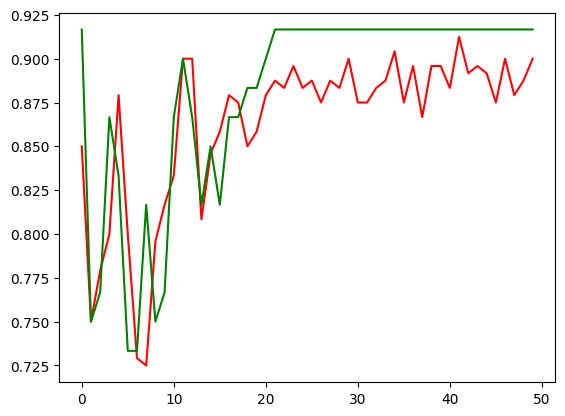

In [52]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color="red")
plt.plot(history.history['val_accuracy'], color="green")
plt.show()

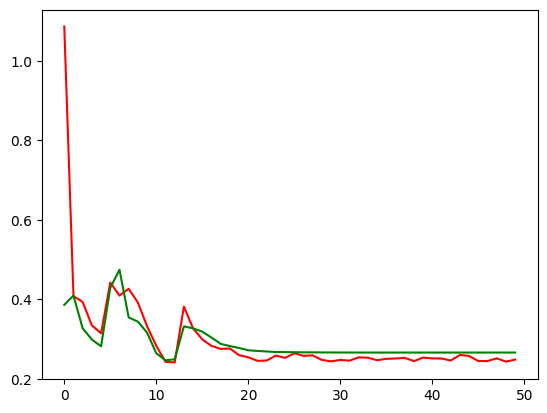

In [53]:
plt.plot(history.history['loss'], color="red")
plt.plot(history.history['val_loss'], color="green")
plt.show()

In [57]:
model.save("/Users/parasningune/Desktop/Best_Models/512_90.42_91.67/model.h5")

In [58]:
model.save_weights("/Users/parasningune/Desktop/Best_Models/512_90.42_91.67/model.weights.h5")

In [34]:






!pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [keras-tuner]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [35]:
import keras_tuner as kt

In [36]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [37]:
sample_path = oil_files[0]

In [38]:
with rasterio.open(sample_path) as src:
    vv = src.read(1).astype(np.float32)
    vh = src.read(2).astype(np.float32)


In [ ]:
def normalize(vv, vh):
    vv = np.clip(vv, -35, 5)
    vh = np.clip(vh, -40, 0)

    vv = (vv + 35) / 40
    vh = (vh + 40) / 40

    return vv, vh

vv, vh = normalize(vv, vh)

In [ ]:
tile_vv = vv[:512, :512]
tile_vh = vh[:512, :512]

In [ ]:
resized = tf.image.resize(
    np.stack([vv, vh], axis=-1),
    (512, 512),
    method="bilinear"
).numpy()

resized_vv = resized[:, :, 0]
resized_vh = resized[:, :, 1]

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(tile_vv, cmap="gray")
plt.title("TRUE TILE VV (512×512)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(resized_vv, cmap="gray")
plt.title("RESIZED VV (2048 → 512)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(tile_vh, cmap="gray")
plt.title("TRUE TILE VH (512×512)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(resized_vh, cmap="gray")
plt.title("RESIZED VH (2048 → 512)")
plt.axis("off")

plt.tight_layout()
plt.show()